In [1]:
from google.colab import files
uploaded = files.upload()

Saving smart-homes-temperature-time-series-forecasting.zip to smart-homes-temperature-time-series-forecasting (5).zip


In [2]:
!unzip smart-homes-temperature-time-series-forecasting.zip

Archive:  smart-homes-temperature-time-series-forecasting.zip
replace Solar house sensors and actuators map.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Load Dataset

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")
df.head()

,Id,Date,Time,CO2_(dinning-room),CO2_room,Relative_humidity_(dinning-room),Relative_humidity_room,Lighting_(dinning-room),Lighting_room,Meteo_Rain,Meteo_Sun_dusk,Meteo_Wind,Meteo_Sun_light_in_west_facade,Meteo_Sun_light_in_east_facade,Meteo_Sun_light_in_south_facade,Meteo_Sun_irradiance,Outdoor_relative_humidity_Sensor,Day_of_the_week,Indoor_temperature_room
0,0,13/03/2012,11:45,216.560,221.920,39.9125,42.4150,81.6650,113.520,0.0,623.360,1.42625,9690.24,12604.20,95436.8,758.880,48.3750,2.0,17.8275
1,1,13/03/2012,12:00,219.947,220.363,39.9267,42.2453,81.7413,113.605,0.0,623.211,1.59200,11022.00,10787.20,95436.8,762.069,47.8080,2.0,18.1207
2,2,13/03/2012,12:15,219.403,218.933,39.7720,42.2267,81.4240,113.600,0.0,622.656,1.89133,13960.50,9669.63,95398.6,766.251,47.4320,2.0,18.4367
3,3,13/03/2012,12:30,218.613,217.045,39.7760,42.0987,81.5013,113.344,0.0,622.571,1.82800,18511.20,9648.13,95360.3,766.037,47.0240,2.0,18.7513
4,4,13/03/2012,12:45,217.714,216.080,39.7757,42.0686,81.4657,113.034,0.0,622.400,2.36071,26349.00,9208.32,95354.9,762.743,45.4743,2.0,19.0414


Dataset Overview

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
df.info()

Dataset Shape:
(2764, 19)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Id                                2764 non-null   int64  
 1   Date                              2764 non-null   object 
 2   Time                              2764 non-null   object 
 3   CO2_(dinning-room)                2764 non-null   float64
 4   CO2_room                          2764 non-null   float64
 5   Relative_humidity_(dinning-room)  2764 non-null   float64
 6   Relative_humidity_room            2764 non-null   float64
 7   Lighting_(dinning-room)           2764 non-null   float64
 8   Lighting_room                     2764 non-null   float64
 9   Meteo_Rain                        2764 non-null   float64
 10  Meteo_Sun_dusk                    2764 non-null   float64
 11  Meteo_Wind                  

In [5]:
df.describe()

,Id,CO2_(dinning-room),CO2_room,Relative_humidity_(dinning-room),Relative_humidity_room,Lighting_(dinning-room),Lighting_room,Meteo_Rain,Meteo_Sun_dusk,Meteo_Wind,Meteo_Sun_light_in_west_facade,Meteo_Sun_light_in_east_facade,Meteo_Sun_light_in_south_facade,Meteo_Sun_irradiance,Outdoor_relative_humidity_Sensor,Day_of_the_week,Indoor_temperature_room
count,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000
mean,1381.500000,208.479123,211.065844,44.878420,47.321220,26.745381,40.732571,0.047033,325.369289,1.108531,14936.617682,12248.000148,22047.525813,215.010017,55.981988,3.954438,18.824852
std,798.042397,27.032686,28.469144,6.587440,7.557795,23.298441,42.326087,0.206705,305.062614,1.161283,25964.049455,21758.550527,32709.387051,297.234046,13.019610,1.991799,2.821178
min,0.000000,187.339000,188.907000,27.084000,29.594700,10.740000,11.328000,0.000000,0.606667,0.000000,0.000000,0.000000,0.000000,-4.164670,22.260700,1.000000,11.076000
25%,690.750000,200.893250,202.682750,40.351975,42.531325,11.588700,13.265300,0.000000,0.650000,0.094833,0.000000,0.000000,0.000000,-3.381330,46.430675,2.000000,17.060350
50%,1381.500000,207.045500,209.408000,45.434650,47.534700,11.801300,17.690000,0.000000,611.797000,0.659000,0.000000,0.000000,0.000000,3.922000,57.477350,4.000000,19.021000
75%,2072.250000,211.245500,213.218750,49.352675,52.685975,31.224000,52.057350,0.000000,619.210750,1.971497,15088.000000,11131.275000,38736.575000,435.434500,65.649325,6.000000,20.828700
max,2763.000000,594.389000,609.237000,60.957300,62.594700,110.693000,162.965000,1.000000,624.960000,6.321330,95278.400000,85535.400000,95704.400000,1028.270000,83.805300,7.000000,24.944000


Data Preprocessing

In [6]:
df.isnull().sum()

,0
Id,0
Date,0
Time,0
CO2_(dinning-room),0
CO2_room,0
Relative_humidity_(dinning-room),0
Relative_humidity_room,0
Lighting_(dinning-room),0
Lighting_room,0
Meteo_Rain,0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

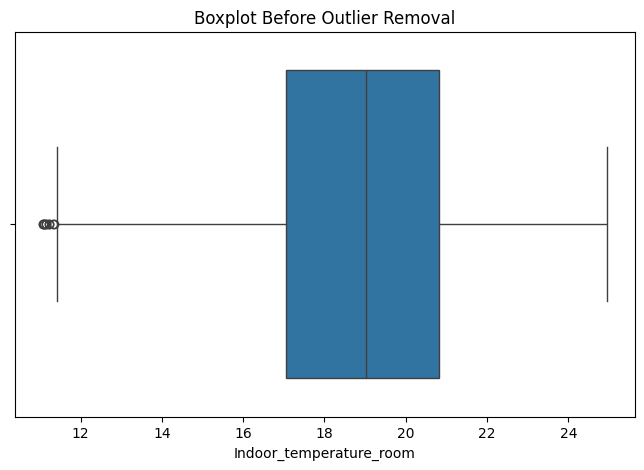

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Indoor_temperature_room"])
plt.title("Boxplot Before Outlier Removal")
plt.show()

In [14]:
num_df = df.select_dtypes(include='number')

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

mask = ~((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[mask]

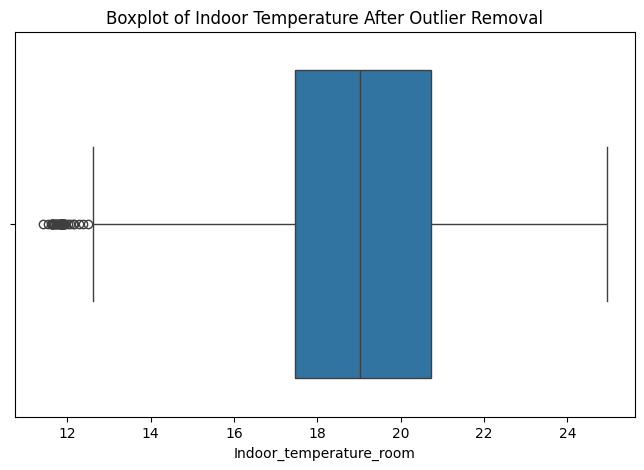

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Indoor_temperature_room"])
plt.title("Boxplot of Indoor Temperature After Outlier Removal")
plt.show()

In [16]:
print("Dataset shape after preprocessing:")
print(df.shape)

Dataset shape after preprocessing:
(1629, 19)


Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

df = df.copy()

scaler = StandardScaler()

num_cols = df.select_dtypes(include='number').columns

df.loc[:, num_cols] = scaler.fit_transform(df[num_cols])

/tmp/ipykernel_59799/233330999.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.79141574 -1.79015572 -1.7888957  ...  1.65600773  1.65726775
  1.65852777]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, num_cols] = scaler.fit_transform(df[num_cols])


In [18]:
print("Scaled dataset preview:")
df.head()

Scaled dataset preview:


,Id,Date,Time,CO2_(dinning-room),CO2_room,Relative_humidity_(dinning-room),Relative_humidity_room,Lighting_(dinning-room),Lighting_room,Meteo_Rain,Meteo_Sun_dusk,Meteo_Wind,Meteo_Sun_light_in_west_facade,Meteo_Sun_light_in_east_facade,Meteo_Sun_light_in_south_facade,Meteo_Sun_irradiance,Outdoor_relative_humidity_Sensor,Day_of_the_week,Indoor_temperature_room
23,-1.791416,2012-03-13,17:30,0.802065,1.034423,-0.674513,-1.330115,1.432914,0.529875,0.0,1.843273,0.743430,0.214623,0.099641,-0.004558,-0.015420,-0.928873,-0.981109,1.938633
24,-1.790156,2012-03-13,17:45,0.780750,1.092588,-0.610909,-1.325520,1.146309,0.531396,0.0,1.840930,0.414828,0.067406,-0.033724,-0.082358,-0.113803,-0.831961,-0.981109,1.984595
25,-1.788896,2012-03-13,18:00,0.742383,1.132273,-0.524805,-1.314121,-0.374249,0.372191,0.0,1.837916,1.219263,-0.146960,-0.310712,-0.261087,-0.228038,-0.638341,-0.981109,2.033122
26,-1.787636,2012-03-13,18:15,0.716805,0.949719,-0.346273,-1.265616,-0.390012,-0.332257,0.0,1.725654,0.582717,-0.330334,-0.356144,-0.304193,-0.314018,-0.430763,-0.981109,2.076020
27,-1.786376,2012-03-13,18:30,0.630079,1.010612,-0.253844,-1.120267,-0.390012,-0.354922,0.0,0.018120,0.352880,-0.330334,-0.356144,-0.304193,-0.324453,-0.305512,-0.981109,1.957554


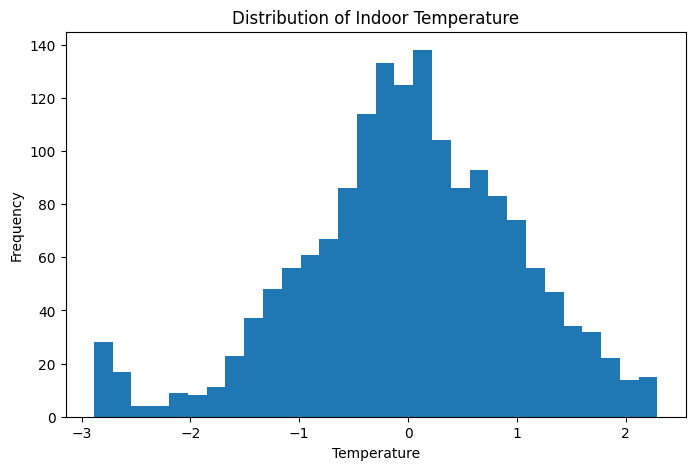

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Indoor_temperature_room'], bins=30)
plt.title("Distribution of Indoor Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

Create DateTime Column

In [20]:
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])

Visualization

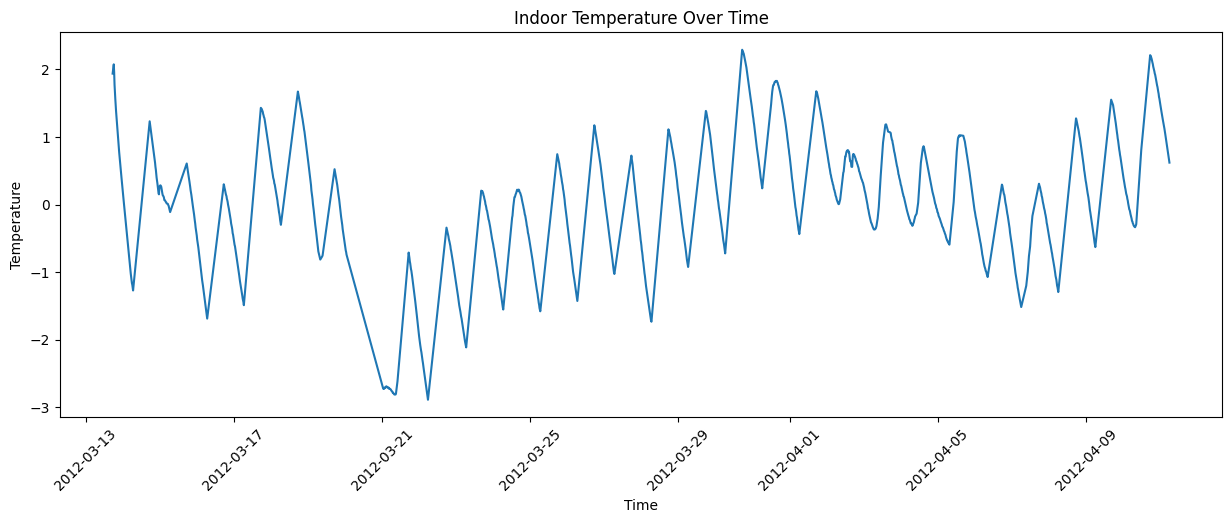

In [21]:
plt.figure(figsize=(15,5))
plt.plot(df['DateTime'], df['Indoor_temperature_room'])
plt.title("Indoor Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

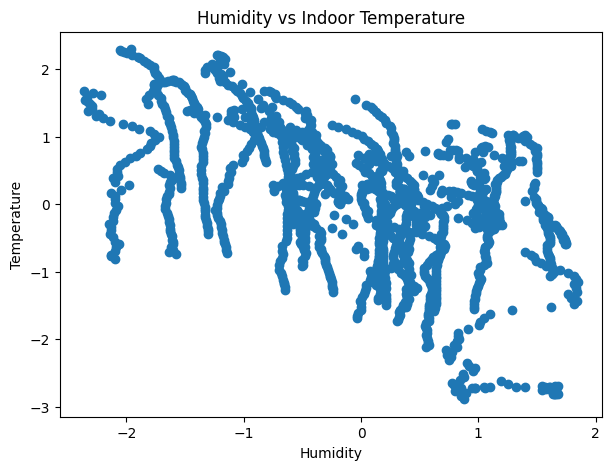

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(df['Relative_humidity_room'], df['Indoor_temperature_room'])
plt.title("Humidity vs Indoor Temperature")
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.show()

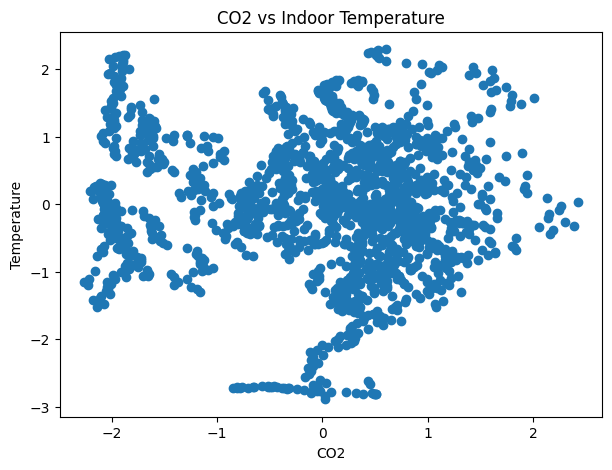

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(df['CO2_room'], df['Indoor_temperature_room'])
plt.title("CO2 vs Indoor Temperature")
plt.xlabel("CO2")
plt.ylabel("Temperature")
plt.show()

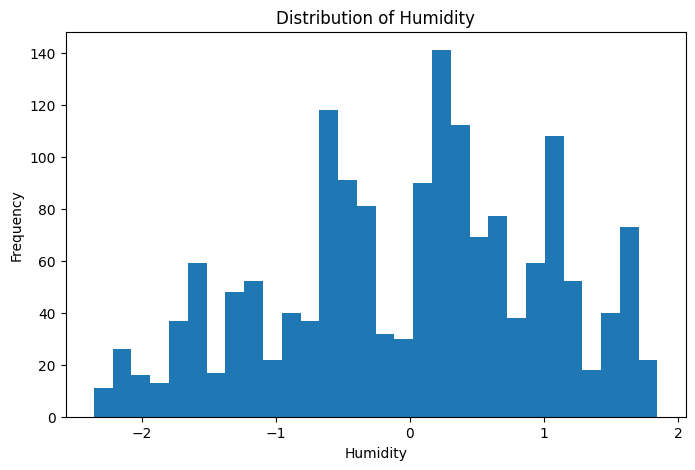

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["Relative_humidity_room"], bins=30)
plt.title("Distribution of Humidity")
plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.show()

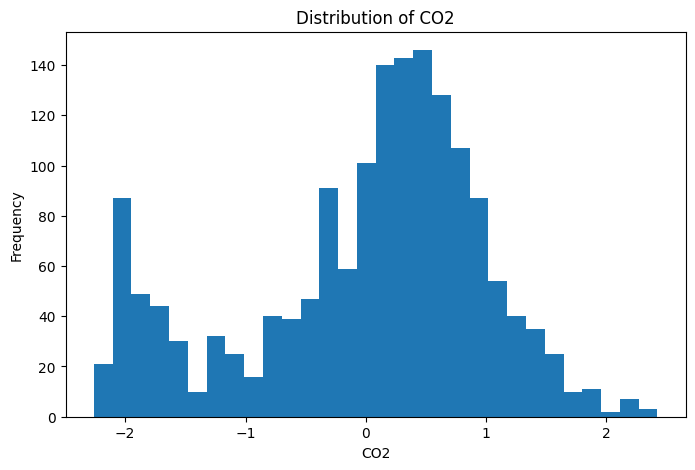

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["CO2_room"], bins=30)
plt.title("Distribution of CO2")
plt.xlabel("CO2")
plt.ylabel("Frequency")
plt.show()

######Correlation Heatmap

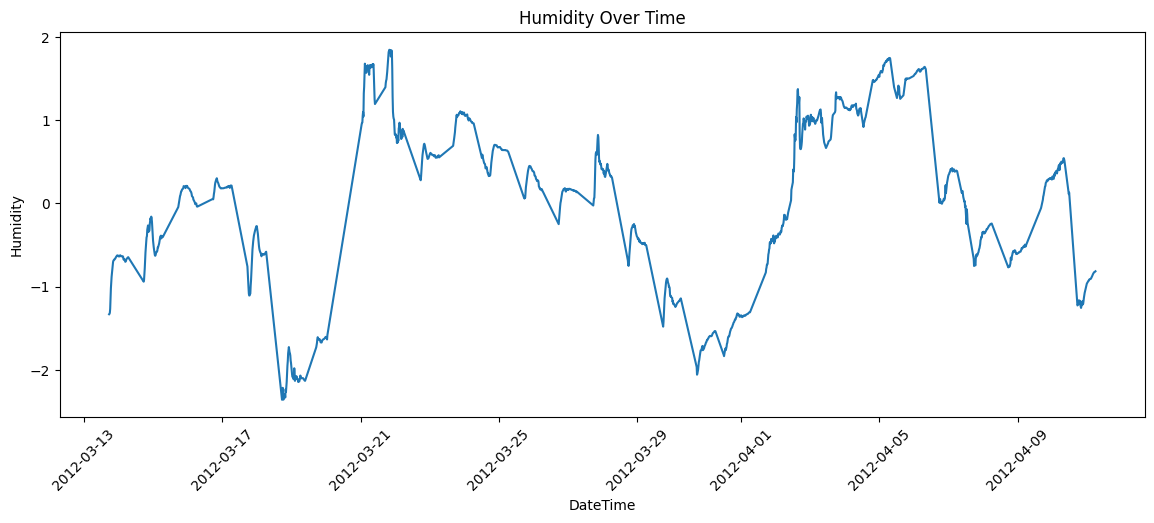

In [27]:
plt.figure(figsize=(14,5))
plt.plot(df["DateTime"], df["Relative_humidity_room"])
plt.title("Humidity Over Time")
plt.xlabel("DateTime")
plt.ylabel("Humidity")
plt.xticks(rotation=45)
plt.show()

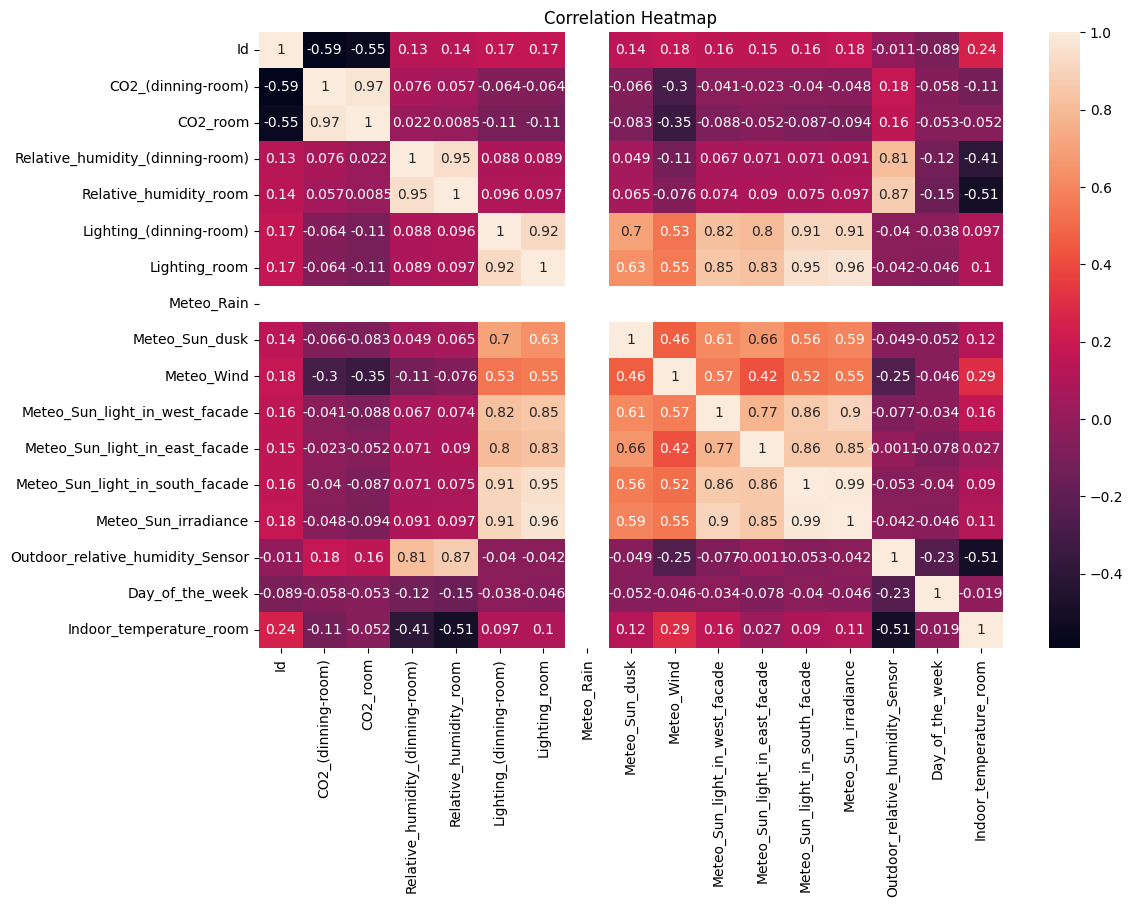

In [28]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Machine Learning Model:

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

target = "Indoor_temperature_room"

features = [
    "CO2_room",
    "Relative_humidity_room",
    "Lighting_room",
    "Meteo_Rain",
    "Meteo_Wind",
    "Outdoor_relative_humidity_Sensor",
    "Day_of_the_week"
]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


Feature Importance

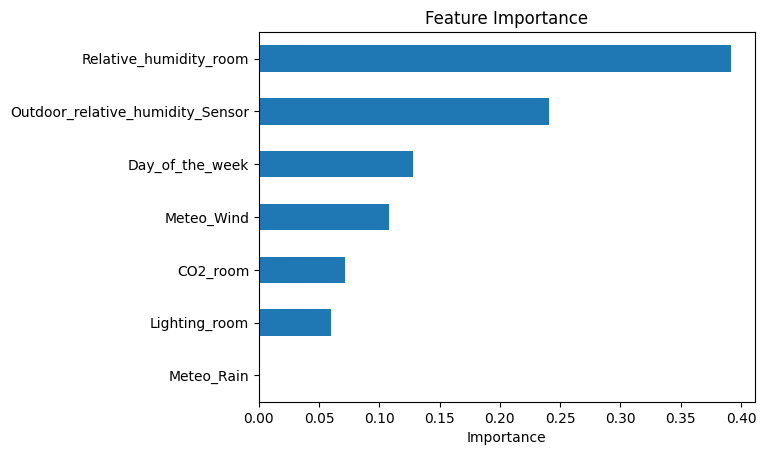

In [30]:
pd.Series(model.feature_importances_, index=features).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

Model Evaluation

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("The model achieved excellent performance.")

MAE: 0.20134049691582015
RMSE: 0.30535446492867707
R2 Score: 0.9103066740100504
The model achieved excellent performance.


Prediction Results

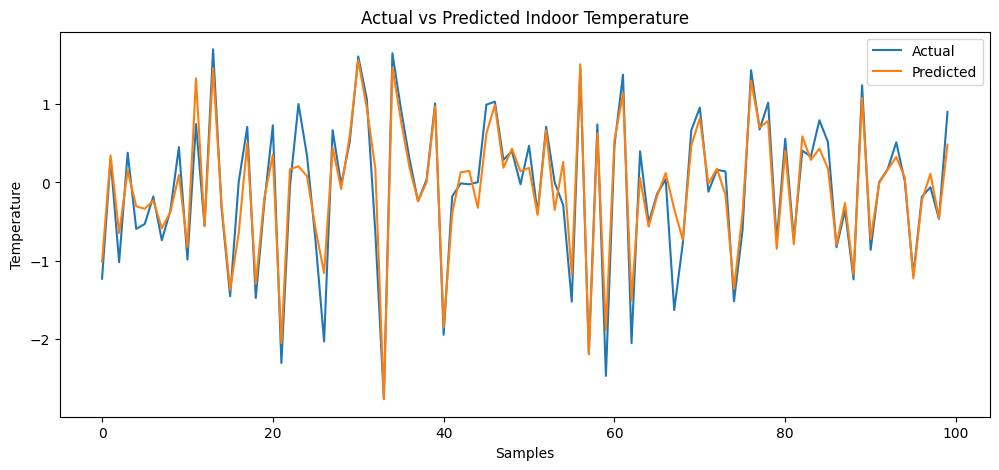

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.title("Actual vs Predicted Indoor Temperature")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.legend()
plt.show()